# V2-B - MM-Fit (sw_r IMU) mit Focal Loss

Dieses Notebook implementiert die **V1-Pipeline** gemäß den festgelegten Entscheidungen:

- nur rechte Smartwatch (`sw_r_acc` + `sw_r_gyr`)
- 50 Hz Resampling
- 5s Fenster (`250` Samples)
- Majority-Label pro Fenster
- 11 Klassen (10 Übungen + `non-exercise`)
- feste Paper-Splits


V2-B hält Architektur und Datenpipeline zu V1 konstant und ersetzt nur die Loss-Funktion durch Sparse Focal Loss.


In [1]:
# Basis-Setup
import os
import random
from pathlib import Path

# Matplotlib-Cache in ein beschreibbares Verzeichnis legen (verhindert Warnungen)
os.environ["MPLCONFIGDIR"] = str(Path.cwd() / ".mplconfig")
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)


/Users/kacharino/myProjects/Bachelor/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow: 2.20.0


In [2]:
# Konfiguration (V2-B)
DATA_ROOT = Path("mm-fit")
FS_TARGET = 50.0
DT_MS = int(round(1000.0 / FS_TARGET))  # 20 ms
WINDOW_SIZE = 250                        # 5 Sekunden @ 50Hz
STRIDE_SAMPLES = int(0.2 * FS_TARGET)    # 0.2 Sekunden -> 10 Samples
BATCH_SIZE = 128
EPOCHS = 40

# Paper-Splits (Workout IDs)
TRAIN_IDS = [1, 2, 3, 4, 6, 7, 8, 16, 17, 18]
VAL_IDS = [14, 15, 19]
TEST_SEEN_IDS = [9, 10, 11]
TEST_UNSEEN_IDS = [0, 5, 12, 13, 20]

EXERCISE_ORDER = [
    "squats",
    "lunges",
    "bicep_curls",
    "situps",
    "pushups",
    "tricep_extensions",
    "dumbbell_rows",
    "jumping_jacks",
    "dumbbell_shoulder_press",
    "lateral_shoulder_raises",
    "non-exercise",
]

label_to_id = {name: i for i, name in enumerate(EXERCISE_ORDER)}
id_to_label = {i: name for name, i in label_to_id.items()}
N_CLASSES = len(EXERCISE_ORDER)

print("Klassen:", label_to_id)


# V2-B: Focal-Loss Parameter
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = None  # None => keine Klassenpriorisierung via alpha


Klassen: {'squats': 0, 'lunges': 1, 'bicep_curls': 2, 'situps': 3, 'pushups': 4, 'tricep_extensions': 5, 'dumbbell_rows': 6, 'jumping_jacks': 7, 'dumbbell_shoulder_press': 8, 'lateral_shoulder_raises': 9, 'non-exercise': 10}


In [3]:
# Hilfsfunktionen: Laden, Label-Mapping, Resampling

def session_name(session_id: int) -> str:
    return f"w{session_id:02d}"


def load_session_raw(session_id: int):
    """Lädt sw_r_acc, sw_r_gyr und Labels einer Session."""
    w = session_name(session_id)
    base = DATA_ROOT / w

    acc = np.load(base / f"{w}_sw_r_acc.npy")
    gyr = np.load(base / f"{w}_sw_r_gyr.npy")

    labels = pd.read_csv(
        base / f"{w}_labels.csv",
        header=None,
        names=["start", "end", "reps", "exercise"],
    )

    return acc, gyr, labels


def assign_labels_by_frame(frames: np.ndarray, labels_df: pd.DataFrame) -> np.ndarray:
    """
    Weist jedem Sensor-Sample auf Basis der Frame-ID ein Klassenlabel zu.
    Alles außerhalb der Übungsintervalle wird als non-exercise markiert.
    """
    y = np.full(frames.shape[0], label_to_id["non-exercise"], dtype=np.int32)

    for _, row in labels_df.iterrows():
        ex = row["exercise"]
        if ex not in label_to_id:
            # Falls unerwartete Labels auftreten, überspringen.
            continue
        mask = (frames >= int(row["start"])) & (frames <= int(row["end"]))
        y[mask] = label_to_id[ex]

    return y


def resample_sw_r_to_50hz(acc: np.ndarray, gyr: np.ndarray, labels_df: pd.DataFrame):
    """
    Resampled acc/gyr auf 50Hz und erzeugt zeitlich ausgerichtete Labels.
    acc/gyr Format: [frame_id, timestamp_ms, x, y, z]
    """
    # Sortieren nach Zeit für stabile Interpolation
    acc = acc[np.argsort(acc[:, 1])]
    gyr = gyr[np.argsort(gyr[:, 1])]

    acc_ts = acc[:, 1].astype(np.float64)
    gyr_ts = gyr[:, 1].astype(np.float64)

    t_start = max(acc_ts.min(), gyr_ts.min())
    t_end = min(acc_ts.max(), gyr_ts.max())
    new_ts = np.arange(t_start, t_end + 1, DT_MS, dtype=np.float64)

    if new_ts.size < WINDOW_SIZE:
        raise ValueError("Session zu kurz nach Resampling.")

    # Lineare Interpolation pro Achse
    acc_xyz = np.stack([
        np.interp(new_ts, acc_ts, acc[:, 2]),
        np.interp(new_ts, acc_ts, acc[:, 3]),
        np.interp(new_ts, acc_ts, acc[:, 4]),
    ], axis=1)

    gyr_xyz = np.stack([
        np.interp(new_ts, gyr_ts, gyr[:, 2]),
        np.interp(new_ts, gyr_ts, gyr[:, 3]),
        np.interp(new_ts, gyr_ts, gyr[:, 4]),
    ], axis=1)

    # Frame-basiertes Labeling zunächst auf ACC-Samples,
    # danach nearest-neighbour auf Resample-Timestamps
    acc_frames = acc[:, 0].astype(np.int64)
    acc_labels = assign_labels_by_frame(acc_frames, labels_df)

    nearest_idx = np.searchsorted(acc_ts, new_ts, side="left")
    nearest_idx = np.clip(nearest_idx, 0, len(acc_ts) - 1)

    prev_idx = np.clip(nearest_idx - 1, 0, len(acc_ts) - 1)
    choose_prev = np.abs(acc_ts[prev_idx] - new_ts) < np.abs(acc_ts[nearest_idx] - new_ts)
    nn_idx = np.where(choose_prev, prev_idx, nearest_idx)

    y_resampled = acc_labels[nn_idx]

    x_resampled = np.concatenate([acc_xyz, gyr_xyz], axis=1).astype(np.float32)
    y_resampled = y_resampled.astype(np.int32)

    return x_resampled, y_resampled


In [4]:
# Daten für alle Sessions vorbereiten
session_data = {}
all_ids = list(range(21))

for sid in all_ids:
    acc, gyr, labels = load_session_raw(sid)
    x, y = resample_sw_r_to_50hz(acc, gyr, labels)
    session_data[sid] = {"x": x, "y": y}

print("Fertig. Anzahl Sessions:", len(session_data))
print("Beispiel w00 Shape:", session_data[0]["x"].shape, session_data[0]["y"].shape)


Fertig. Anzahl Sessions: 21
Beispiel w00 Shape: (106765, 6) (106765,)


In [5]:
# Normalisierung (nur mit Train-Sessions fitten)

def fit_standardizer(train_ids):
    x_all = np.concatenate([session_data[sid]["x"] for sid in train_ids], axis=0)
    mean = x_all.mean(axis=0)
    std = x_all.std(axis=0) + 1e-6
    return mean.astype(np.float32), std.astype(np.float32)


mean_vec, std_vec = fit_standardizer(TRAIN_IDS)

for sid in all_ids:
    session_data[sid]["x"] = (session_data[sid]["x"] - mean_vec) / std_vec

print("Normalisierung gesetzt (train-only fit).")
print("Mean:", np.round(mean_vec, 4))
print("Std:", np.round(std_vec, 4))


Normalisierung gesetzt (train-only fit).
Mean: [ 4.2045 -3.3051  1.9853 -0.0049 -0.0077 -0.005 ]
Std: [6.3585 4.8538 4.3254 1.0802 0.8402 0.9931]


In [6]:
# Fenster-Indizes + Majority-Labels

def majority_labels_for_starts(y: np.ndarray, starts: np.ndarray, window: int, n_classes: int):
    # Präfixsummen pro Klasse für effiziente Fenster-Counts
    pref = np.zeros((n_classes, y.size + 1), dtype=np.int32)
    for c in range(n_classes):
        pref[c, 1:] = np.cumsum(y == c)

    end = starts + window
    counts = pref[:, end] - pref[:, starts]
    maj = np.argmax(counts, axis=0).astype(np.int32)
    return maj


def build_split_index(split_ids, stride=STRIDE_SAMPLES):
    sess_col = []
    start_col = []
    label_col = []

    for sid in split_ids:
        y = session_data[sid]["y"]
        max_start = len(y) - WINDOW_SIZE
        if max_start < 0:
            continue

        starts = np.arange(0, max_start + 1, stride, dtype=np.int32)
        maj = majority_labels_for_starts(y, starts, WINDOW_SIZE, N_CLASSES)

        sess_col.append(np.full(starts.shape[0], sid, dtype=np.int16))
        start_col.append(starts)
        label_col.append(maj)

    sess_col = np.concatenate(sess_col)
    start_col = np.concatenate(start_col)
    label_col = np.concatenate(label_col)

    return sess_col, start_col, label_col


train_sess, train_start, train_lab = build_split_index(TRAIN_IDS)
val_sess, val_start, val_lab = build_split_index(VAL_IDS)
seen_sess, seen_start, seen_lab = build_split_index(TEST_SEEN_IDS)
unseen_sess, unseen_start, unseen_lab = build_split_index(TEST_UNSEEN_IDS)

print("Train windows:", len(train_lab))
print("Val windows:", len(val_lab))
print("Test seen windows:", len(seen_lab))
print("Test unseen windows:", len(unseen_lab))


Train windows: 119123
Val windows: 26138
Test seen windows: 41041
Test unseen windows: 60128


In [7]:
# Daten-Generator für Keras
class WindowSequence(tf.keras.utils.Sequence):
    def __init__(self, sess_ids, starts, labels, batch_size=128, shuffle=False):
        self.sess_ids = sess_ids
        self.starts = starts
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.labels))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.labels) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        sl = slice(idx * self.batch_size, (idx + 1) * self.batch_size)
        batch_ids = self.indices[sl]

        x_batch = np.empty((len(batch_ids), WINDOW_SIZE, 6), dtype=np.float32)
        y_batch = self.labels[batch_ids]

        for i, j in enumerate(batch_ids):
            sid = int(self.sess_ids[j])
            st = int(self.starts[j])
            x_batch[i] = session_data[sid]["x"][st:st + WINDOW_SIZE]

        return x_batch, y_batch


train_seq = WindowSequence(train_sess, train_start, train_lab, batch_size=BATCH_SIZE, shuffle=True)
val_seq = WindowSequence(val_sess, val_start, val_lab, batch_size=BATCH_SIZE, shuffle=False)
seen_seq = WindowSequence(seen_sess, seen_start, seen_lab, batch_size=BATCH_SIZE, shuffle=False)
unseen_seq = WindowSequence(unseen_sess, unseen_start, unseen_lab, batch_size=BATCH_SIZE, shuffle=False)

print("Sequences bereit.")


Sequences bereit.


In [8]:
# Klassenverteilung pro Split (nach Majority-Window-Labels)
def print_distribution(name, labels):
    vals, cnt = np.unique(labels, return_counts=True)
    total = cnt.sum()
    print(f"\n{name} ({total} windows)")
    for v, c in zip(vals, cnt):
        print(f"  {id_to_label[int(v)]:26s}: {c:7d} ({(c/total)*100:5.2f}%)")

print_distribution("Train", train_lab)
print_distribution("Validation", val_lab)
print_distribution("Test Seen", seen_lab)
print_distribution("Test Unseen", unseen_lab)



Train (119123 windows)
  squats                    :    3159 ( 2.65%)
  lunges                    :    4112 ( 3.45%)
  bicep_curls               :    2653 ( 2.23%)
  situps                    :    4019 ( 3.37%)
  pushups                   :    2596 ( 2.18%)
  tricep_extensions         :    3264 ( 2.74%)
  dumbbell_rows             :    2804 ( 2.35%)
  jumping_jacks             :    1559 ( 1.31%)
  dumbbell_shoulder_press   :    3566 ( 2.99%)
  lateral_shoulder_raises   :    3584 ( 3.01%)
  non-exercise              :   87807 (73.71%)

Validation (26138 windows)
  squats                    :     849 ( 3.25%)
  lunges                    :    1246 ( 4.77%)
  bicep_curls               :     990 ( 3.79%)
  situps                    :    1192 ( 4.56%)
  pushups                   :     835 ( 3.19%)
  tricep_extensions         :     921 ( 3.52%)
  dumbbell_rows             :     766 ( 2.93%)
  jumping_jacks             :     308 ( 1.18%)
  dumbbell_shoulder_press   :    1167 ( 4.46%)
  latera

In [9]:
# Sparse Focal Loss (für integer Labels)
def make_sparse_focal_loss(gamma=2.0, alpha=None):
    def loss_fn(y_true, y_pred):
        y_true_int = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        num_classes = tf.shape(y_pred)[-1]

        y_true_oh = tf.one_hot(y_true_int, depth=num_classes, dtype=y_pred.dtype)
        y_pred_clipped = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        pt = tf.reduce_sum(y_true_oh * y_pred_clipped, axis=-1)
        ce = -tf.math.log(pt)

        if alpha is None:
            alpha_t = 1.0
        else:
            alpha_vec = tf.convert_to_tensor(alpha, dtype=y_pred.dtype)
            alpha_t = tf.gather(alpha_vec, y_true_int)

        focal = alpha_t * tf.pow(1.0 - pt, gamma) * ce
        return tf.reduce_mean(focal)

    return loss_fn


focal_loss = make_sparse_focal_loss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA)
print(f"Focal loss aktiv: gamma={FOCAL_GAMMA}, alpha={FOCAL_ALPHA}")


Focal loss aktiv: gamma=2.0, alpha=None


In [10]:
# Modell: zwei Branches (acc/gyr), paper-inspiriert

def build_v1_model(input_shape=(WINDOW_SIZE, 6), n_classes=N_CLASSES):
    inp = tf.keras.Input(shape=input_shape)

    acc = inp[:, :, :3]
    gyr = inp[:, :, 3:]

    def branch(x, prefix):
        x = tf.keras.layers.Conv1D(9, 11, strides=2, padding="same", groups=3, activation="relu", name=f"{prefix}_conv1")(x)
        x = tf.keras.layers.Conv1D(15, 11, strides=2, padding="same", groups=3, activation="relu", name=f"{prefix}_conv2")(x)
        x = tf.keras.layers.Conv1D(24, 11, strides=2, padding="same", activation="relu", name=f"{prefix}_conv3")(x)
        x = tf.keras.layers.Flatten(name=f"{prefix}_flatten")(x)
        return x

    acc_f = branch(acc, "acc")
    gyr_f = branch(gyr, "gyr")

    x = tf.keras.layers.Concatenate(name="concat_features")([acc_f, gyr_f])
    x = tf.keras.layers.Dense(100, activation="relu", name="fc1")(x)
    x = tf.keras.layers.Dense(100, activation="relu", name="fc2")(x)
    x = tf.keras.layers.Dense(100, activation="relu", name="fc3")(x)
    out = tf.keras.layers.Dense(n_classes, activation="softmax", name="clf")(x)

    model = tf.keras.Model(inputs=inp, outputs=out, name="v1_sw_r_paper_like")
    return model


model = build_v1_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=focal_loss,
    metrics=["accuracy"],
)
model.summary()


Model: "v1_sw_r_paper_like"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 250, 6)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 250, 3)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 250, 3)    │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ acc_conv1 (Conv1D)  │ (None, 125, 9)    │        108 │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gyr_conv1 (Conv1D)  │ (None, 125, 9)    │        108 │ get_item_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ acc_conv2 (Conv1D)  │ (None, 63, 15)    │        510 │ acc_conv1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gyr_conv2 (Conv1D)  │ (None, 63, 15)    │        510 │ gyr_conv1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ acc_conv3 (Conv1D)  │ (None, 32, 24)    │      3,984 │ acc_conv2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gyr_conv3 (Conv1D)  │ (None, 32, 24)    │      3,984 │ gyr_conv2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ acc_flatten         │ (None, 768)       │          0 │ acc_conv3[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gyr_flatten         │ (None, 768)       │          0 │ gyr_conv3[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_features     │ (None, 1536)      │          0 │ acc_flatten[0][0… │
│ (Concatenate)       │                   │            │ gyr_flatten[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 100)       │    153,700 │ concat_features[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc2 (Dense)         │ (None, 100)       │     10,100 │ fc1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc3 (Dense)         │ (None, 100)       │     10,100 │ fc2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clf (Dense)         │ (None, 11)        │      1,111 │ fc3[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 184,215 (719.59 KB)

 Trainable params: 184,215 (719.59 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Training
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.1,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_v2b_sw_r_focal.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    train_seq,
    validation_data=val_seq,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/40


/Users/kacharino/myProjects/Bachelor/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


  1/931 ━━━━━━━━━━━━━━━━━━━━ 21:08 1s/step - accuracy: 0.0625 - loss: 1.9783

2026-02-27 14:19:50.134300: I external/local_xla/xla/service/service.cc:163] XLA service 0x9b1accd00 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-02-27 14:19:50.134313: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1772198390.192687  550687 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  3/931 ━━━━━━━━━━━━━━━━━━━━ 30s 33ms/step - accuracy: 0.3077 - loss: 1.9418

...


Epoch 14: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.



Epoch 14: val_accuracy did not improve from 0.94169


931/931 ━━━━━━━━━━━━━━━━━━━━ 34s 36ms/step - accuracy: 0.9984 - loss: 0.0012 - val_accuracy: 0.9366 - val_loss: 0.3037 - learning_rate: 1.0000e-04


Epoch 14: early stopping


Restoring model weights from the end of the best epoch: 4.


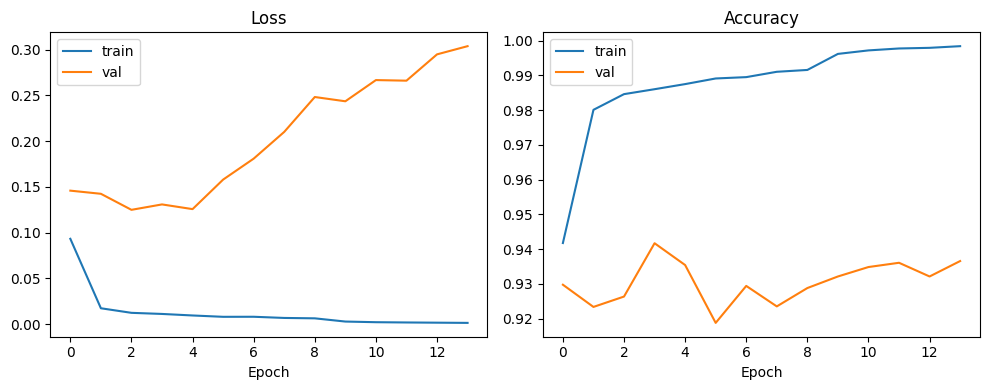

In [12]:
# Lernkurven
hist = history.history

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(hist["loss"], label="train")
plt.plot(hist["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist["accuracy"], label="train")
plt.plot(hist["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
# Evaluation-Funktionen

def predict_from_sequence(model, seq):
    y_true = []
    y_pred = []

    for xb, yb in seq:
        probs = model.predict(xb, verbose=0)
        pred = np.argmax(probs, axis=1)
        y_true.append(yb)
        y_pred.append(pred)

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    return y_true, y_pred


def evaluate_split(name, seq):
    y_true, y_pred = predict_from_sequence(model, seq)
    acc = (y_true == y_pred).mean()
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"\n[{name}] Accuracy: {acc:.4f} | Macro-F1: {macro_f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=[id_to_label[i] for i in range(N_CLASSES)], digits=4))

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(N_CLASSES))
    return y_true, y_pred, cm


In [14]:
# Ergebnisse: Seen / Unseen
y_seen_true, y_seen_pred, cm_seen = evaluate_split("Test Seen", seen_seq)
y_unseen_true, y_unseen_pred, cm_unseen = evaluate_split("Test Unseen", unseen_seq)



[Test Seen] Accuracy: 0.9851 | Macro-F1: 0.9696
                         precision    recall  f1-score   support

                 squats     0.9773    0.9659    0.9716      1026
                 lunges     0.9698    0.9814    0.9756      1343
            bicep_curls     0.9641    0.8200    0.8862       950
                 situps     0.9538    0.9858    0.9696      1341
                pushups     0.9899    0.9752    0.9825       808
      tricep_extensions     0.9925    0.9741    0.9832      1082
          dumbbell_rows     0.9939    0.9533    0.9732       857
          jumping_jacks     0.9956    0.9473    0.9708       474
dumbbell_shoulder_press     0.9781    0.9732    0.9757      1194
lateral_shoulder_raises     0.9945    0.9792    0.9868      1105
           non-exercise     0.9871    0.9937    0.9904     30861

               accuracy                         0.9851     41041
              macro avg     0.9815    0.9590    0.9696     41041
           weighted avg     0.9850    0


[Test Unseen] Accuracy: 0.9379 | Macro-F1: 0.8429
                         precision    recall  f1-score   support

                 squats     0.8991    0.4181    0.5708      1471
                 lunges     0.9725    0.6741    0.7963      2096
            bicep_curls     0.9423    0.7035    0.8056      1231
                 situps     0.8583    0.6680    0.7513      1696
                pushups     0.9752    0.8786    0.9244      1120
      tricep_extensions     0.9933    0.8678    0.9263      1195
          dumbbell_rows     0.9610    0.9319    0.9462      1189
          jumping_jacks     0.9606    0.9098    0.9345       643
dumbbell_shoulder_press     0.9592    0.9629    0.9611      1051
lateral_shoulder_raises     0.7422    0.6448    0.6901      1188
           non-exercise     0.9403    0.9921    0.9655     47248

               accuracy                         0.9379     60128
              macro avg     0.9276    0.7865    0.8429     60128
           weighted avg     0.9369   

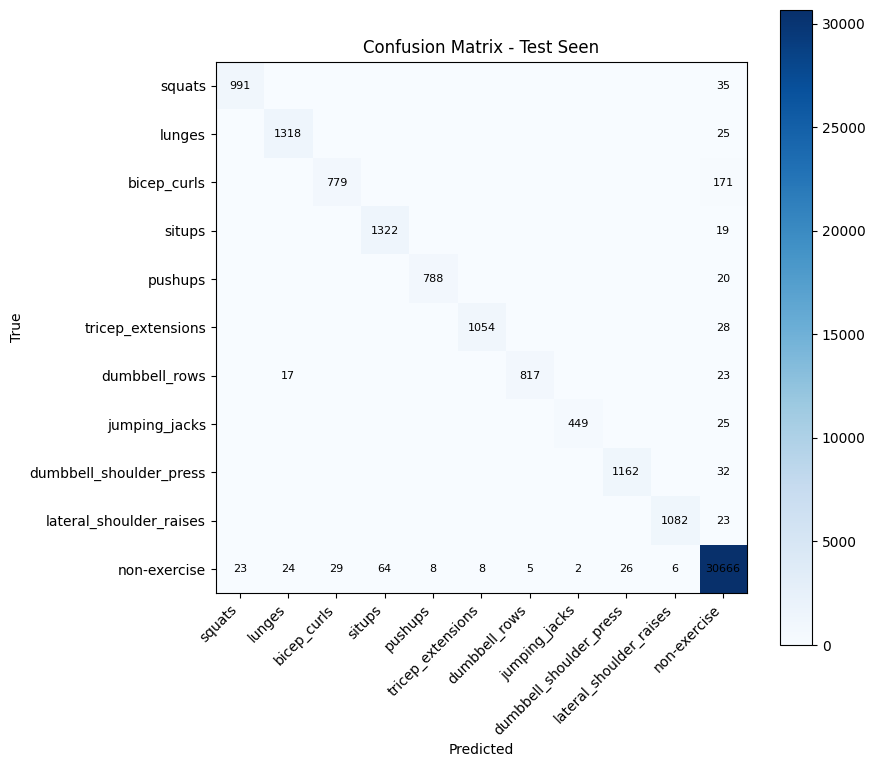

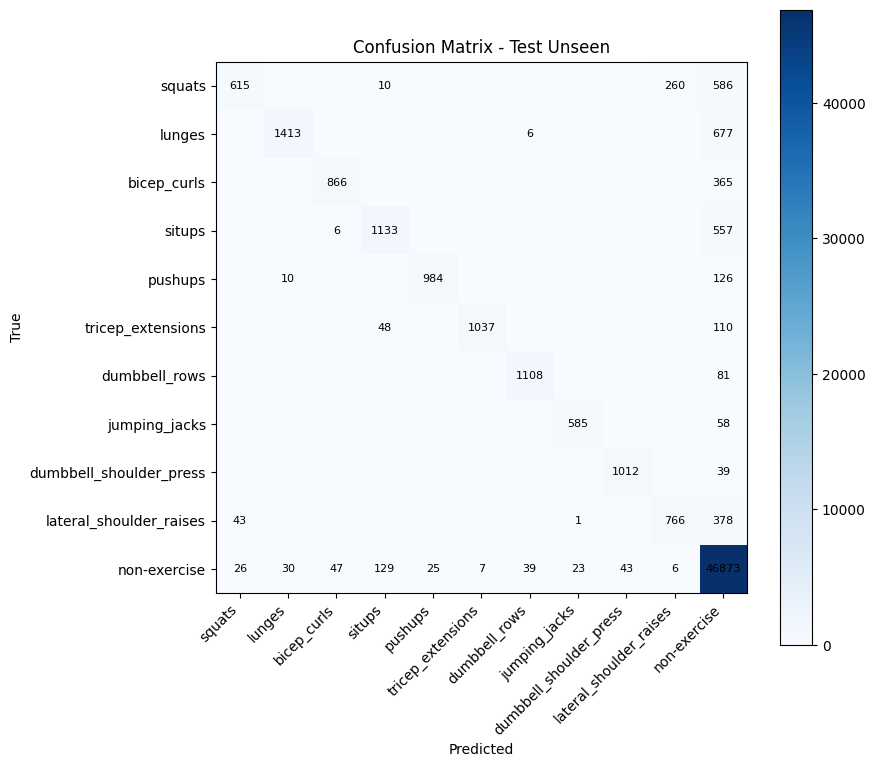

In [15]:
# Konfusionsmatrix-Plot

def plot_cm(cm, title):
    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(np.arange(N_CLASSES))
    ax.set_yticks(np.arange(N_CLASSES))
    ax.set_xticklabels([id_to_label[i] for i in range(N_CLASSES)], rotation=45, ha="right")
    ax.set_yticklabels([id_to_label[i] for i in range(N_CLASSES)])

    # leichte Annotation für Lesbarkeit
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            v = cm[i, j]
            if v > 0:
                ax.text(j, i, str(v), ha="center", va="center", fontsize=8)

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


plot_cm(cm_seen, "Confusion Matrix - Test Seen")
plot_cm(cm_unseen, "Confusion Matrix - Test Unseen")


In [16]:
# Artefakte speichern
artifacts = {
    "config": {
        "fs_target": FS_TARGET,
        "window_size": WINDOW_SIZE,
        "stride_samples": STRIDE_SAMPLES,
        "class_order": EXERCISE_ORDER,
        "train_ids": TRAIN_IDS,
        "val_ids": VAL_IDS,
        "test_seen_ids": TEST_SEEN_IDS,
        "test_unseen_ids": TEST_UNSEEN_IDS,
        "seed": SEED,
    },
    "normalization": {
        "mean": mean_vec.tolist(),
        "std": std_vec.tolist(),
    },
}

import json
with open("v2b_sw_r_artifacts.json", "w", encoding="utf-8") as f:
    json.dump(artifacts, f, indent=2)

print("Gespeichert: best_v2b_sw_r_focal.keras, v2b_sw_r_artifacts.json")


Gespeichert: best_v2b_sw_r_focal.keras, v2b_sw_r_artifacts.json
